# Importar Bibliotecas Requeridas
Importa las bibliotecas necesarias como NumPy, Pandas y scikit-learn para el manejo de datos y el entrenamiento del modelo.

In [1]:
# Importar Bibliotecas Requeridas
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Verificar Valores Faltantes
Verifica si hay valores NaN en el conjunto de datos antes del preprocesamiento.

In [2]:
# Verificar Valores Faltantes
df_check = pd.read_csv('../DARA_PROC/combined_features.csv')
print("Total de valores NaN en el conjunto de datos:", df_check.isna().sum().sum())
print("Valores NaN por columna:")
print(df_check.isna().sum())
print("\nTotal de valores cero en las características:", (df_check[['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']] == 0).sum().sum())

Total de valores NaN en el conjunto de datos: 0
Valores NaN por columna:
UNIX Timestamp       0
DateTime             0
ECG_mean             0
ECG_std              0
ECG_range            0
ECG_energy           0
ECG_samp_ent         0
ECG_missing_peaks    0
SDNN                 0
RMSSD                0
pNN50                0
HR_mean              0
HR_max               0
HR_min               0
FatigueIndex         0
dtype: int64

Total de valores cero en las características: 7404


# Cargar y Preparar Datos
Carga el conjunto de datos desde combined_features.csv y realiza preprocesamiento como manejar valores faltantes.

In [3]:
# Cargar y Preparar Datos
df = pd.read_csv('../DARA_PROC/combined_features.csv')

# Seleccionar características y objetivo
features = ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
target = 'FatigueIndex'

X = df[features]
y = df[target]

# Manejar valores faltantes (si los hay)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Dividir Datos en Conjuntos de Entrenamiento y Prueba
Usa train_test_split de scikit-learn para dividir los datos en subconjuntos de entrenamiento y prueba.

In [4]:
# Dividir Datos en Conjuntos de Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Elegir e Inicializar un Modelo
Selecciona un algoritmo de aprendizaje automático (ej. LinearRegression) e inicializa el modelo con parámetros predeterminados o personalizados.

In [5]:
# Elegir e Inicializar un Modelo
model = LinearRegression()

# Entrenar el Modelo
Ajusta el modelo a los datos de entrenamiento usando el método fit().

In [6]:
# Entrenar el Modelo
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Evaluar el Rendimiento del Modelo
Evalúa el modelo usando métricas como el error cuadrático medio o R-cuadrado en el conjunto de prueba.

In [7]:
# Evaluar el Rendimiento del Modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# MSE: Error Cuadrático Medio - menor es mejor (0 es perfecto)
print(f'Mean Squared Error: {mse}')
# RMSE: Raíz del Error Cuadrático Medio - menor es mejor, en unidades del objetivo
print(f'Root Mean Squared Error: {rmse}')
# MAE: Error Absoluto Medio - menor es mejor, menos sensible a outliers que MSE
print(f'Mean Absolute Error: {mae}')
# R²: Coeficiente de Determinación - mayor es mejor (1.0 es perfecto, explica toda la varianza)
print(f'R-squared: {r2}')

Mean Squared Error: 1.3044515928133463e-28
Root Mean Squared Error: 1.1421259093520935e-14
Mean Absolute Error: 5.459991119358295e-15
R-squared: 1.0


# Hacer Predicciones
Usa el modelo entrenado para hacer predicciones en datos nuevos o de prueba con el método predict().

In [8]:
# Hacer Predicciones
# Ejemplo: Predecir en datos de prueba
predictions = model.predict(X_test)
print("Predicciones primeras 5:", predictions[:5])
print("Valores reales primeras 5:", y_test.iloc[:5].values)
print("Errores (Pred - Real) primeras 5:", predictions[:5] - y_test.iloc[:5].values)

Predicciones primeras 5: [-5.40354776 -4.99209565 -5.26389479 -4.723989   -4.97734157]
Valores reales primeras 5: [-5.40354776 -4.99209565 -5.26389479 -4.723989   -4.97734157]
Errores (Pred - Real) primeras 5: [-1.77635684e-15 -8.88178420e-16 -2.66453526e-15 -1.77635684e-15
 -1.77635684e-15]


# Importancia de Características (Coeficientes)

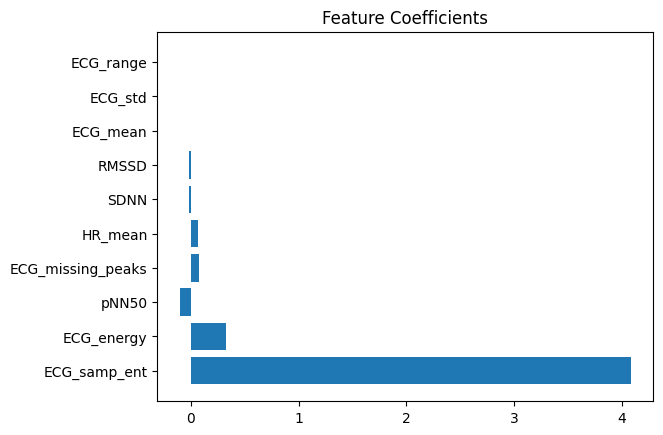

ECG_mean: -0.0000
ECG_std: 0.0000
ECG_range: -0.0000
ECG_energy: 0.3296
ECG_samp_ent: 4.0812
ECG_missing_peaks: 0.0729
SDNN: -0.0158
RMSSD: -0.0140
pNN50: -0.1017
HR_mean: 0.0677
HR_max: 0.0000
HR_min: 0.0000


In [9]:
# Importancia de Características (Coeficientes)
coefficients = model.coef_
feature_names = X_train.columns
# Sort by absolute value for top 10
sorted_idx = np.argsort(np.abs(coefficients))[::-1][:10]
plt.barh(feature_names[sorted_idx], coefficients[sorted_idx])
plt.title("Feature Coefficients")
plt.show()

# Imprimir los coeficientes numéricamente
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

# Experimento 2: Entrenamiento sin Características de HR y HRV

In [10]:
# Experimento 2: Entrenar sin características de HR y HRV
# Remover HR_mean, SDNN, RMSSD, pNN50, HR_max, HR_min de X_train y X_test
features_to_remove = ['HR_mean', 'SDNN', 'RMSSD', 'pNN50', 'HR_max', 'HR_min']
X_train_new = X_train.drop(columns=features_to_remove)
X_test_new = X_test.drop(columns=features_to_remove)

# y_train, y_test permanecen iguales

In [11]:
# Elegir e Inicializar un Modelo (Experimento 2)
model2 = LinearRegression()

In [12]:
# Entrenar el Modelo (Experimento 2)
model2.fit(X_train_new, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Evaluar el Rendimiento del Modelo (Experimento 2)
y_pred2 = model2.predict(X_test_new)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

# MSE: Error Cuadrático Medio - menor es mejor (0 es perfecto)
print(f'Mean Squared Error (Exp2): {mse2}')
# RMSE: Raíz del Error Cuadrático Medio - menor es mejor, en unidades del objetivo
print(f'Root Mean Squared Error (Exp2): {rmse2}')
# MAE: Error Absoluto Medio - menor es mejor, menos sensible a outliers que MSE
print(f'Mean Absolute Error (Exp2): {mae2}')
# R²: Coeficiente de Determinación - mayor es mejor (1.0 es perfecto, explica toda la varianza)
print(f'R-squared (Exp2): {r22}')

Mean Squared Error (Exp2): 0.2659301777637264
Root Mean Squared Error (Exp2): 0.5156841841318448
Mean Absolute Error (Exp2): 0.2336183238903926
R-squared (Exp2): 0.9698779048985501


In [14]:
# Hacer Predicciones (Experimento 2)
predictions2 = model2.predict(X_test_new)
print("Predicciones primeras 5 (Exp2):", predictions2[:5])
print("Valores reales primeras 5:", y_test.iloc[:5].values)
print("Errores (Pred - Real) primeras 5 (Exp2):", predictions2[:5] - y_test.iloc[:5].values)

Predicciones primeras 5 (Exp2): [-5.35993738 -4.95191904 -5.20083112 -4.64628989 -4.90924806]
Valores reales primeras 5: [-5.40354776 -4.99209565 -5.26389479 -4.723989   -4.97734157]
Errores (Pred - Real) primeras 5 (Exp2): [0.04361038 0.04017661 0.06306367 0.07769911 0.06809351]


# Importancia de Características (Coeficientes) - Experimento 2

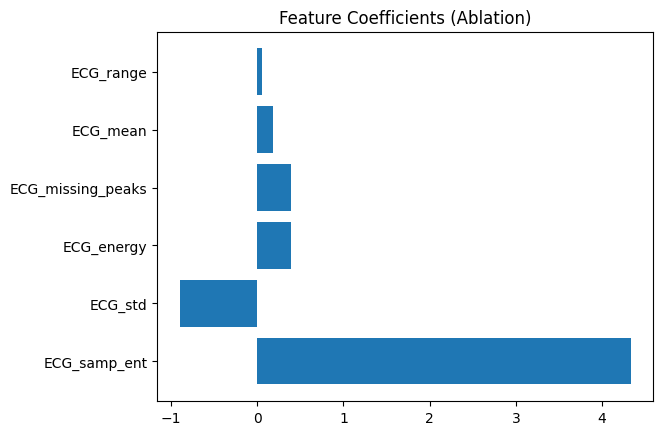

ECG_mean: 0.1776
ECG_std: -0.8968
ECG_range: 0.0574
ECG_energy: 0.3958
ECG_samp_ent: 4.3335
ECG_missing_peaks: 0.3927


In [15]:
# Importancia de Características (Coeficientes) - Experimento 2
coefficients2 = model2.coef_
feature_names2 = X_train_new.columns
# Sort by absolute value for top 10
sorted_idx2 = np.argsort(np.abs(coefficients2))[::-1][:10]
plt.barh(feature_names2[sorted_idx2], coefficients2[sorted_idx2])
plt.title("Feature Coefficients (Ablation)")
plt.show()

# Imprimir los coeficientes numéricamente
for name, coef in zip(feature_names2, coefficients2):
    print(f"{name}: {coef:.4f}")

# Guardar el Modelo Entrenado
Guarda el modelo entrenado en un archivo para poder cargarlo posteriormente y hacer inferencias.

In [16]:
# Guardar el Modelo Entrenado (Experimento 1)
joblib.dump(model, 'linear_regression_model.pkl')
print("Modelo guardado como 'linear_regression_model.pkl'")

Modelo guardado como 'linear_regression_model.pkl'


In [17]:
# Guardar el Modelo Entrenado (Experimento 2)
joblib.dump(model2, 'linear_regression_model_ablation.pkl')
print("Modelo de ablación guardado como 'linear_regression_model_ablation.pkl'")

Modelo de ablación guardado como 'linear_regression_model_ablation.pkl'


# Hacer Predicciones en Datos Nuevos (W02)
Carga los modelos guardados y haz predicciones en el conjunto de datos de W02.

In [18]:
# Cargar Datos Nuevos de W02
df_new = pd.read_csv('../../W02/DARA_PROC/combined_features.csv')

# Seleccionar características (mismas que para entrenamiento)
features = ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
X_new = df_new[features]
y_new_true = df_new['FatigueIndex']  # Valores reales para comparación

# Manejar valores faltantes
X_new = X_new.fillna(X_new.mean())

print(f"Datos nuevos cargados: {len(df_new)} filas")
print("Primeras 5 filas de características:")
print(X_new.head())

Datos nuevos cargados: 1196 filas
Primeras 5 filas de características:
   ECG_mean   ECG_std  ECG_range  ECG_energy  ECG_samp_ent  ECG_missing_peaks  \
0 -0.052159  0.251022      2.082    0.065716      0.172175                  0   
1 -0.031559  0.239518      1.910    0.058350      0.125951                  0   
2 -0.033732  0.233719      1.848    0.055748      0.118515                  0   
3 -0.031086  0.252801      2.379    0.064858      0.134955                  0   
4 -0.030045  0.250969      2.076    0.063872      0.130991                  0   

   SDNN  RMSSD  pNN50  HR_mean  HR_max  HR_min  
0   0.0    0.0    0.0      0.0     0.0     0.0  
1   0.0    0.0    0.0      0.0     0.0     0.0  
2   0.0    0.0    0.0      0.0     0.0     0.0  
3   0.0    0.0    0.0      0.0     0.0     0.0  
4   0.0    0.0    0.0      0.0     0.0     0.0  


In [19]:
# Cargar Modelo 1 y Hacer Predicciones
model_loaded = joblib.load('linear_regression_model.pkl')
predictions_new = model_loaded.predict(X_new)

print("Predicciones Modelo 1 (con todas las características) - primeras 5:")
print(predictions_new[:5])
print("Valores reales - primeras 5:")
print(y_new_true.iloc[:5].values)

# Calcular métricas en datos nuevos
mse_new = mean_squared_error(y_new_true, predictions_new)
rmse_new = np.sqrt(mse_new)
mae_new = mean_absolute_error(y_new_true, predictions_new)
r2_new = r2_score(y_new_true, predictions_new)

print(f"\nMétricas en datos nuevos (Modelo 1):")
print(f'Mean Squared Error: {mse_new}')
print(f'Root Mean Squared Error: {rmse_new}')
print(f'Mean Absolute Error: {mae_new}')
print(f'R-squared: {r2_new}')

Predicciones Modelo 1 (con todas las características) - primeras 5:
[-5.161377   -5.35245516 -5.38366268 -5.31356362 -5.33006868]
Valores reales - primeras 5:
[-6.34767337 -6.622922   -6.6677565  -6.56732831 -6.59107388]

Métricas en datos nuevos (Modelo 1):
Mean Squared Error: 6.149205040882876
Root Mean Squared Error: 2.4797590691199973
Mean Absolute Error: 1.6307864129941354
R-squared: 0.3244561266803313


In [20]:
# Preparar Datos para Modelo 2 (sin HR y HRV)
features_ablation = ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks']
X_new_ablation = X_new[features_ablation]

# Cargar Modelo 2 y Hacer Predicciones
model2_loaded = joblib.load('linear_regression_model_ablation.pkl')
predictions_new2 = model2_loaded.predict(X_new_ablation)

print("Predicciones Modelo 2 (sin HR/HRV) - primeras 5:")
print(predictions_new2[:5])
print("Valores reales - primeras 5:")
print(y_new_true.iloc[:5].values)

# Calcular métricas en datos nuevos
mse_new2 = mean_squared_error(y_new_true, predictions_new2)
rmse_new2 = np.sqrt(mse_new2)
mae_new2 = mean_absolute_error(y_new_true, predictions_new2)
r2_new2 = r2_score(y_new_true, predictions_new2)

print(f"\nMétricas en datos nuevos (Modelo 2):")
print(f'Mean Squared Error: {mse_new2}')
print(f'Root Mean Squared Error: {rmse_new2}')
print(f'Mean Absolute Error: {mae_new2}')
print(f'R-squared: {r2_new2}')

Predicciones Modelo 2 (sin HR/HRV) - primeras 5:
[-5.09401756 -5.29315091 -5.32515317 -5.23644303 -5.26959205]
Valores reales - primeras 5:
[-6.34767337 -6.622922   -6.6677565  -6.56732831 -6.59107388]

Métricas en datos nuevos (Modelo 2):
Mean Squared Error: 5.058867292278394
Root Mean Squared Error: 2.2491925867471627
Mean Absolute Error: 1.7091659988122716
R-squared: 0.4442392500307222


# Hacer Predicciones en Datos Nuevos (W03)
Carga los modelos guardados y haz predicciones en el conjunto de datos de W03.

In [21]:
# Cargar Datos Nuevos de W03
df_new3 = pd.read_csv('../../W03/DARA_PROC/combined_features.csv')

# Seleccionar características (mismas que para entrenamiento)
X_new3 = df_new3[features]
y_new3_true = df_new3['FatigueIndex']  # Valores reales para comparación

# Manejar valores faltantes
X_new3 = X_new3.fillna(X_new3.mean())

print(f"Datos nuevos de W03 cargados: {len(df_new3)} filas")
print("Primeras 5 filas de características:")
print(X_new3.head())

Datos nuevos de W03 cargados: 813 filas
Primeras 5 filas de características:
   ECG_mean   ECG_std  ECG_range  ECG_energy  ECG_samp_ent  ECG_missing_peaks  \
0  0.000000  0.000000      0.000    0.000000      0.000000                  0   
1  0.000000  0.000000      0.000    0.000000      0.000000                  0   
2 -0.179477  0.179609      2.533    0.064463      0.204267                  0   
3 -0.159360  0.175685      2.417    0.056253      0.292866                  0   
4 -0.149837  0.199667      2.580    0.062308      0.248107                  0   

   SDNN  RMSSD  pNN50  HR_mean  HR_max  HR_min  
0   0.0    0.0    0.0      0.0     0.0     0.0  
1   0.0    0.0    0.0      0.0     0.0     0.0  
2   0.0    0.0    0.0      0.0     0.0     0.0  
3   0.0    0.0    0.0      0.0     0.0     0.0  
4   0.0    0.0    0.0      0.0     0.0     0.0  


In [22]:
# Cargar Modelo 1 y Hacer Predicciones en W03
predictions_new3 = model_loaded.predict(X_new3)

print("Predicciones Modelo 1 en W03 - primeras 5:")
print(predictions_new3[:5])
print("Valores reales W03 - primeras 5:")
print(y_new3_true.iloc[:5].values)

# Calcular métricas en datos de W03
mse_new3 = mean_squared_error(y_new3_true, predictions_new3)
rmse_new3 = np.sqrt(mse_new3)
mae_new3 = mean_absolute_error(y_new3_true, predictions_new3)
r2_new3 = r2_score(y_new3_true, predictions_new3)

print(f"\nMétricas en datos de W03 (Modelo 1):")
print(f'Mean Squared Error: {mse_new3}')
print(f'Root Mean Squared Error: {rmse_new3}')
print(f'Mean Absolute Error: {mae_new3}')
print(f'R-squared: {r2_new3}')

Predicciones Modelo 1 en W03 - primeras 5:
[-5.88572446 -5.88572446 -5.0308158  -4.67193084 -4.85260581]
Valores reales W03 - primeras 5:
[-8.14855799 -8.14855799 -7.27459269 -7.01206618 -7.13854502]

Métricas en datos de W03 (Modelo 1):
Mean Squared Error: 9.92217304133936
Root Mean Squared Error: 3.1499481013723636
Mean Absolute Error: 2.9194901926681216
R-squared: 0.173272371275916


In [23]:
# Preparar Datos para Modelo 2 en W03 (sin HR y HRV)
X_new3_ablation = X_new3[features_ablation]

# Hacer Predicciones con Modelo 2 en W03
predictions_new3_2 = model2_loaded.predict(X_new3_ablation)

print("Predicciones Modelo 2 en W03 - primeras 5:")
print(predictions_new3_2[:5])
print("Valores reales W03 - primeras 5:")
print(y_new3_true.iloc[:5].values)

# Calcular métricas en datos de W03
mse_new3_2 = mean_squared_error(y_new3_true, predictions_new3_2)
rmse_new3_2 = np.sqrt(mse_new3_2)
mae_new3_2 = mean_absolute_error(y_new3_true, predictions_new3_2)
r2_new3_2 = r2_score(y_new3_true, predictions_new3_2)

print(f"\nMétricas en datos de W03 (Modelo 2):")
print(f'Mean Squared Error: {mse_new3_2}')
print(f'Root Mean Squared Error: {rmse_new3_2}')
print(f'Mean Absolute Error: {mae_new3_2}')
print(f'R-squared: {r2_new3_2}')

Predicciones Modelo 2 en W03 - primeras 5:
[-5.75137491 -5.75137491 -4.88809834 -4.50697795 -4.70899694]
Valores reales W03 - primeras 5:
[-8.14855799 -8.14855799 -7.27459269 -7.01206618 -7.13854502]

Métricas en datos de W03 (Modelo 2):
Mean Squared Error: 12.609531663390918
Root Mean Squared Error: 3.550990237017122
Mean Absolute Error: 2.9059289979711944
R-squared: -0.0506416455310319
